In [ ]:
from google.colab import files
uploaded = files.upload()

Saving METABRIC_RNA_nomut.csv to METABRIC_RNA_nomut.csv


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import io
df = pd.read_csv(io.StringIO(uploaded['METABRIC_RNA_nomut.csv'].decode('utf-8')))

In [ ]:
df.info()
df.columns
len(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 520 entries, patient_id to ugt2b7
dtypes: float64(496), int64(7), object(17)
memory usage: 7.6+ MB


1904

In [ ]:
# elist = [df.columns[678], df.columns[688], df.columns[690], df.columns[692]]
# for name in elist:
#   df[name] = df[name].astype(str)
#   print(df[name].unique())

In [ ]:
for i in range(df.shape[1]):
  if (df[df.columns[i]].dtype == "object"):
    df[df.columns[i]] = df[df.columns[i]].str.upper().str.strip()


In [ ]:
for i in range(df.shape[1]):
  print(df.columns[i])
  print(df[df.columns[i]].unique())
  print()

patient_id
[   0    2    5 ... 7297 7298 7299]

age_at_diagnosis
[75.65 43.19 48.87 ... 43.1  42.88 60.02]

type_of_breast_surgery
['MASTECTOMY' 'BREAST CONSERVING' nan]

cancer_type
['BREAST CANCER' 'BREAST SARCOMA']

cancer_type_detailed
['BREAST INVASIVE DUCTAL CARCINOMA'
 'BREAST MIXED DUCTAL AND LOBULAR CARCINOMA'
 'BREAST INVASIVE LOBULAR CARCINOMA'
 'BREAST INVASIVE MIXED MUCINOUS CARCINOMA' 'BREAST' nan
 'METAPLASTIC BREAST CANCER']

cellularity
[nan 'HIGH' 'MODERATE' 'LOW']

chemotherapy
[0 1]

pam50_+_claudin-low_subtype
['CLAUDIN-LOW' 'LUMA' 'LUMB' 'HER2' 'NORMAL' 'BASAL' 'NC']

cohort
[1 2 3 5 4]

er_status_measured_by_ihc
['POSITVE' 'NEGATIVE' nan]

er_status
['POSITIVE' 'NEGATIVE']

neoplasm_histologic_grade
[ 3.  2.  1. nan]

her2_status_measured_by_snp6
['NEUTRAL' 'LOSS' 'GAIN' 'UNDEF']

her2_status
['NEGATIVE' 'POSITIVE']

tumor_other_histologic_subtype
['DUCTAL/NST' 'MIXED' 'LOBULAR' 'TUBULAR/ CRIBRIFORM' 'MUCINOUS'
 'MEDULLARY' 'OTHER' nan 'METAPLASTIC']

hormone_the

In [ ]:
# check for NaN in ROWS
count = 0
n_rows = len(df)
for i in range(n_rows):
  for item in df.iloc[i]:
    if pd.isna(item):
      count += 1
      print(i, df.iloc[i])
      break
print("\n\n other isna check")
print(df[df.isna().any(axis=1)])
print(count)
print(count/n_rows)


Streaming output truncated to the last 5000 lines.
cancer_type                                  BREAST CANCER
cancer_type_detailed      BREAST INVASIVE DUCTAL CARCINOMA
                                        ...               
tnk2                                                1.2364
tulp4                                               1.2358
ugt2b15                                            -0.4772
ugt2b17                                            -0.1815
ugt2b7                                             -0.6851
Name: 1374, Length: 520, dtype: object
1381 patient_id                                             5463
age_at_diagnosis                                      71.91
type_of_breast_surgery                           MASTECTOMY
cancer_type                                   BREAST CANCER
cancer_type_detailed      BREAST INVASIVE LOBULAR CARCINOMA
                                        ...                
tnk2                                                 2.3383
tulp4        

In [ ]:
# only ordinal is cellularity.
df['cellularity'] = df['cellularity'].map({'LOW': 1, 'MODERATE': 2, 'HIGH': 3}).fillna(df['cellularity'].map({'LOW': 1, 'MODERATE': 2, 'HIGH': 3}).median())
# if pd.isna(df['cellularity'][0]):
#   print('abc')
# print(df["cellularity"].unique())


In [ ]:
# numerical
for i in range(df.shape[1]):
  if df[df.columns[i]].dtype != "object":
    df[df.columns[i]] = df[df.columns[i]].fillna(df[df.columns[i]].median())
print(df.isna().sum())


patient_id                 0
age_at_diagnosis           0
type_of_breast_surgery    22
cancer_type                0
cancer_type_detailed      15
                          ..
tnk2                       0
tulp4                      0
ugt2b15                    0
ugt2b17                    0
ugt2b7                     0
Length: 520, dtype: int64


In [ ]:
# nominal
df = pd.get_dummies(df, columns=df.select_dtypes(include=['object']).columns, dummy_na=True, dtype=int)
print(df)

      patient_id  age_at_diagnosis  cellularity  chemotherapy  cohort  \
0              0             75.65          3.0             0       1   
1              2             43.19          3.0             0       1   
2              5             48.87          3.0             1       1   
3              6             47.68          2.0             1       1   
4              8             76.97          3.0             1       1   
...          ...               ...          ...           ...     ...   
1899        7295             43.10          3.0             0       4   
1900        7296             42.88          3.0             0       4   
1901        7297             62.90          3.0             0       4   
1902        7298             61.16          2.0             0       4   
1903        7299             60.02          3.0             0       4   

      neoplasm_histologic_grade  hormone_therapy  \
0                           3.0                1   
1                  

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print(df.shape)
print(df.columns)

(1904, 585)
Index(['patient_id', 'age_at_diagnosis', 'cellularity', 'chemotherapy',
       'cohort', 'neoplasm_histologic_grade', 'hormone_therapy',
       'lymph_nodes_examined_positive', 'mutation_count',
       'nottingham_prognostic_index',
       ...
       'pr_status_nan', '3-gene_classifier_subtype_ER+/HER2- HIGH PROLIF',
       '3-gene_classifier_subtype_ER+/HER2- LOW PROLIF',
       '3-gene_classifier_subtype_ER-/HER2-',
       '3-gene_classifier_subtype_HER2+', '3-gene_classifier_subtype_nan',
       'death_from_cancer_DIED OF DISEASE',
       'death_from_cancer_DIED OF OTHER CAUSES', 'death_from_cancer_LIVING',
       'death_from_cancer_nan'],
      dtype='object', length=585)


given that person has died, what is survival time? based off of factors
remove "death of" and y value is survival time in years (change overall months to years)

 - remove survival rates from db (eg
 - tr/val/test

In [ ]:
main_df = df.loc[df['overall_survival'] == 0].copy()
print(main_df)
print(main_df['overall_survival'])

      patient_id  age_at_diagnosis  cellularity  chemotherapy  cohort  \
2              5             48.87          3.0             1       1   
4              8             76.97          3.0             1       1   
5             10             78.77          2.0             0       1   
7             22             89.08          2.0             0       1   
8             28             86.41          2.0             0       1   
...          ...               ...          ...           ...     ...   
1898        7294             59.20          3.0             0       4   
1900        7296             42.88          3.0             0       4   
1901        7297             62.90          3.0             0       4   
1902        7298             61.16          2.0             0       4   
1903        7299             60.02          3.0             0       4   

      neoplasm_histologic_grade  hormone_therapy  \
2                           2.0                1   
4                  

In [ ]:
drop_cols = ['overall_survival', 'cohort', 'nottingham_prognostic_index']
drop_cols += [c for c in main_df.columns if c.startswith('death_from_cancer_')]
main_df = main_df.drop(columns=drop_cols, errors='ignore')

In [ ]:
main_df = main_df.reset_index(drop=True)
display(main_df.head())

,patient_id,age_at_diagnosis,cellularity,chemotherapy,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,overall_survival_months,radio_therapy,...,oncotree_code_MDLC,oncotree_code_nan,pr_status_NEGATIVE,pr_status_POSITIVE,pr_status_nan,3-gene_classifier_subtype_ER+/HER2- HIGH PROLIF,3-gene_classifier_subtype_ER+/HER2- LOW PROLIF,3-gene_classifier_subtype_ER-/HER2-,3-gene_classifier_subtype_HER2+,3-gene_classifier_subtype_nan
0,5,48.87,3.0,1,2.0,1,1,2.0,163.700000,0,...,0,0,0,1,0,0,0,0,0,1
1,8,76.97,3.0,1,3.0,1,8,2.0,41.366667,1,...,1,0,0,1,0,1,0,0,0,0
2,10,78.77,2.0,0,3.0,1,0,4.0,7.800000,1,...,0,0,0,1,0,1,0,0,0,0
3,22,89.08,2.0,0,2.0,1,1,1.0,99.533333,1,...,1,0,1,0,0,0,0,0,0,1
4,28,86.41,2.0,0,3.0,1,1,4.0,36.566667,1,...,0,0,1,0,0,1,0,0,0,0


In [ ]:
# patient id dict (row:patient_id)
print(main_df['patient_id'])

num_rows = len(main_df)
id_dict = {}
for i in range(num_rows):
  id_dict[i] = main_df.iloc[i]['patient_id']
print(id_dict)
main_df.drop(columns=['patient_id'], inplace=True)

0          5
1          8
2         10
3         22
4         28
        ... 
1098    7294
1099    7296
1100    7297
1101    7298
1102    7299
Name: patient_id, Length: 1103, dtype: int64
{0: np.float64(5.0), 1: np.float64(8.0), 2: np.float64(10.0), 3: np.float64(22.0), 4: np.float64(28.0), 5: np.float64(35.0), 6: np.float64(36.0), 7: np.float64(46.0), 8: np.float64(79.0), 9: np.float64(83.0), 10: np.float64(95.0), 11: np.float64(100.0), 12: np.float64(102.0), 13: np.float64(108.0), 14: np.float64(109.0), 15: np.float64(112.0), 16: np.float64(115.0), 17: np.float64(119.0), 18: np.float64(120.0), 19: np.float64(123.0), 20: np.float64(129.0), 21: np.float64(131.0), 22: np.float64(134.0), 23: np.float64(143.0), 24: np.float64(144.0), 25: np.float64(146.0), 26: np.float64(147.0), 27: np.float64(149.0), 28: np.float64(151.0), 29: np.float64(163.0), 30: np.float64(165.0), 31: np.float64(167.0), 32: np.float64(170.0), 33: np.float64(177.0), 34: np.float64(178.0), 35: np.float64(179.0), 36: np

In [ ]:
main_df.loc[:, 'time_until_death'] = main_df.loc[:, 'overall_survival_months']/12
main_df.drop(columns=['overall_survival_months'], inplace=True)
print(main_df['time_until_death'])

0       13.641667
1        3.447222
2        0.650000
3        8.294444
4        3.047222
          ...    
1098     6.894444
1099     3.727778
1100    14.663889
1101     7.186111
1102    16.825000
Name: time_until_death, Length: 1103, dtype: float64


database sorting above,

TORCH BELOW

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Just for reproducibility: make random numbers repeatable
torch.manual_seed(42)

In [ ]:
# # SAMPLE DATASET

# # Number of samples and features
# N_SAMPLES = 1000
# N_FEATURES = 10

# # Inputs: random normal numbers
# X = torch.randn(N_SAMPLES, N_FEATURES)

# # "True" underlying linear relationship + noise
# true_w = torch.randn(N_FEATURES, 1)
# true_b = torch.tensor([2.0]) # just a constant bias
# y = X @ true_w + true_b # matrix multiply + bias, shape (N_SAMPLES, 1)

# # Make targets non-negative (e.g. like a physical quantity that can't be < 0)
# y = torch.relu(y) # now y >= 0

# # Make sure y is shape (N_SAMPLES, 1)
# print(X.shape, y.shape)

In [ ]:
y_actual = main_df['time_until_death'].values
X_actual = main_df.drop(columns=['time_until_death']).values

# Convert numpy arrays to torch tensors
X = torch.tensor(X_actual, dtype=torch.float32)
y = torch.tensor(y_actual, dtype=torch.float32).unsqueeze(1)

# Update N_FEATURES and N_SAMPLES based on the actual dataset
N_FEATURES = X.shape[1]
N_SAMPLES = X.shape[0]

# Make sure y is shape (N_SAMPLES, 1)
print(X.shape, y.shape)

torch.Size([1103, 576]) torch.Size([1103, 1])


In [ ]:
# Shuffle and split indices
N = N_SAMPLES

indices = torch.randperm(N)
train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: torch.Size([772, 576]) torch.Size([772, 1])
Val:   torch.Size([165, 576]) torch.Size([165, 1])
Test:  torch.Size([166, 576]) torch.Size([166, 1])


In [ ]:
BATCH_SIZE = 32

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class MLP(nn.Module):
  def __init__(self, in_features):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(in_features, 512), # Layer 1
      nn.ReLU(),
      nn.Linear(512, 256),
      nn.ReLU(),
      nn.Linear(256, 128),
      nn.ReLU(),
      nn.Linear(128, 1) # Layer 4 (output) - Removed final ReLU
    )

  def forward(self, x):
    return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(in_features=N_FEATURES).to(device) # Use the dynamically updated N_FEATURES
print(model)
print(f"Using device: {device}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=576, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)
Using device: cuda


In [ ]:
loss_fn = nn.MSELoss()
lrate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lrate)

In [ ]:
NUM_EPOCHS = 100
train_losses = []
val_losses = []

# Initialize for checkpointing
best_val_loss = float('inf') # Initialize with a very high value
best_path = 'best_model.pt'
last_path = 'last_model.pt'

for epoch in range(NUM_EPOCHS):
  # ---------- TRAINING ----------
  model.train() # set model to training mode
  train_loss_total = 0.0
  train_num_samples = 0
  # batch_train_losses = []
  for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device) # Move data to device

    optimizer.zero_grad()

    # Forward pass
    preds = model(xb)
    loss = loss_fn(preds, yb)

    # Backward pass and optimization step
    loss.backward()
    optimizer.step()

# isn't for each batch, loss.item() result of entire batch and thus don't need to multiply by batch size?
    train_loss_total += loss.item() * xb.size(0)
    train_num_samples += xb.size(0)

  avg_train_loss = train_loss_total / train_num_samples
  train_losses.append(avg_train_loss)

  # avg_train_loss = sum(batch_train_losses) / len(batch_train_losses)
  # train_losses.append(avg_train_loss)

  # ---------- VALIDATION ----------
  model.eval() # set model to evaluation mode
  val_loss_total = 0.0
  val_num_samples = 0

  with torch.no_grad(): # no gradients during validation
    for xb, yb in val_loader:
      xb, yb = xb.to(device), yb.to(device) # Move data to device
      preds = model(xb)
      loss = loss_fn(preds, yb)
      # Accumulate loss * number of samples to compute average
      val_loss_total += loss.item() * xb.size(0)
      val_num_samples += xb.size(0)

  avg_val_loss = val_loss_total / val_num_samples
  val_losses.append(avg_val_loss)

  # Print progress every 10 epochs (or every epoch if you like)
  if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} "
      f"- Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

  ckpt = {
      "epoch": epoch,
      "model_state": model.state_dict(),
      "optimizer_state": optimizer.state_dict(),
      "train_losses": train_losses,
      "val_losses": val_losses,
      "best_val_loss": best_val_loss,  # updated below if improved
  }

  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    ckpt["best_val_loss"] = best_val_loss
    torch.save(ckpt, best_path)

  torch.save(ckpt, last_path)

Epoch   1/100 - Train Loss: 89.4710, Val Loss: 65.1409
Epoch  10/100 - Train Loss: 23.3237, Val Loss: 27.9235
Epoch  20/100 - Train Loss: 10.3030, Val Loss: 29.5438
Epoch  30/100 - Train Loss: 2.2201, Val Loss: 32.0502
Epoch  40/100 - Train Loss: 0.3200, Val Loss: 31.9879
Epoch  50/100 - Train Loss: 0.0407, Val Loss: 31.9455
Epoch  60/100 - Train Loss: 0.0095, Val Loss: 31.7576
Epoch  70/100 - Train Loss: 0.0015, Val Loss: 31.8377
Epoch  80/100 - Train Loss: 0.0005, Val Loss: 31.8215
Epoch  90/100 - Train Loss: 0.0011, Val Loss: 32.0260
Epoch 100/100 - Train Loss: 0.1047, Val Loss: 31.8436


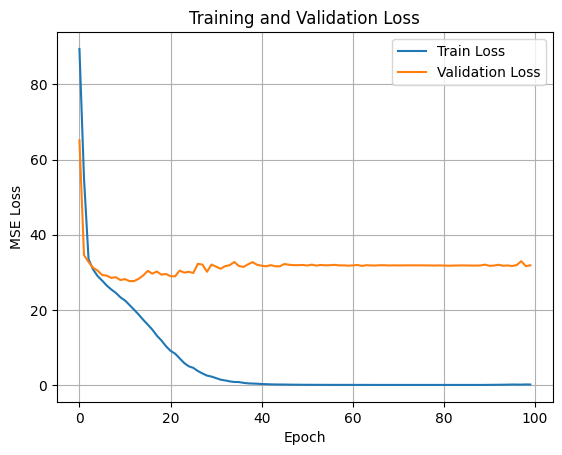

In [ ]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_path = 'best_model.pt'

# Load the best checkpoint
checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])

model.eval()
test_loss_total = 0.0
test_num_samples = 0
with torch.no_grad():
  for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device) # Move data to device
    preds = model(xb)
    mse = loss_fn(preds, yb)
    test_loss_total += mse.item() * xb.size(0)
    test_num_samples += xb.size(0)
    test_mse = test_loss_total / test_num_samples
print(f"Test MSE (from best checkpoint): {test_mse:.4f}")

Test MSE (from best checkpoint): 37.4818


In [ ]:
import numpy as np
import pandas as pd
import torch
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error

def bootstrap_metric_ci(X, y, model, metric_fn, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    n = len(y)
    stats_boot = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        X_b = X.iloc[idx]
        y_b = y.iloc[idx]

        # Convert X_b to tensor and move to device for model prediction
        X_b_tensor = torch.tensor(X_b.values, dtype=torch.float32).to(device)
        # Model prediction returns tensor, convert to numpy for metric_fn
        y_pred_b = model(X_b_tensor).cpu().detach().numpy().flatten() # Added .detach()
        stats_boot.append(metric_fn(y_b.values.flatten(), y_pred_b))

    stats_boot = np.array(stats_boot)
    mean = stats_boot.mean()
    lower = np.percentile(stats_boot, 2.5)
    upper = np.percentile(stats_boot, 97.5)
    return mean, lower, upper

def pearson_metric(y_true, y_pred):
    r, _ = stats.pearsonr(y_true, y_pred)
    return r

def r2_metric(y_true, y_pred):
    return r2_score(y_true, y_pred)

def mse_metric(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

# Convert test data back to DataFrame/Series for bootstrap_metric_ci
X_test_df = pd.DataFrame(X_test.cpu().numpy())
y_test_series = pd.Series(y_test.cpu().numpy().flatten())

pearson_mean, pearson_lo, pearson_hi = bootstrap_metric_ci(
    X_test_df, y_test_series, model, pearson_metric, n_bootstrap=2000
)

r2_mean, r2_lo, r2_hi = bootstrap_metric_ci(
    X_test_df, y_test_series, model, r2_metric, n_bootstrap=2000
)

mse_mean, mse_lo, mse_hi = bootstrap_metric_ci(
    X_test_df, y_test_series, model, mse_metric, n_bootstrap=2000
)

print("Test Pearson:")
print(f"mean = {pearson_mean:.3f}")
print(f"95% CI = [{pearson_lo:.3f}, {pearson_hi:.3f}]")
print()
print("Test r2:")
print(f"mean = {r2_mean:.3f}")
print(f"95% CI = [{r2_lo:.3f}, {r2_hi:.3f}]")
print()
print("Test mse:")
print(f"mse = {mse_mean:.3f}")
print(f"95% CI = [{mse_lo:.3f}, {mse_hi:.3f}]")

Test Pearson:
mean = 0.288
95% CI = [0.148, 0.416]

Test r2:
mean = 0.052
95% CI = [-0.061, 0.161]

Test mse:
mse = 37.414
95% CI = [29.191, 46.972]


torch.Size([4, 576]) torch.Size([4, 1]) torch.Size([4, 1])
[array([ 6.059351 ,  9.263668 ,  5.825016 , 11.476375 ,  6.108268 ,
        3.9955938,  9.204857 ,  6.568832 ,  7.0312266,  4.7774696,
        2.6409597,  7.2014785, 10.811867 ,  9.313579 ,  3.5848165,
        6.184167 ,  7.369595 ,  6.9748588, 10.358841 , 13.640271 ,
        4.5155144,  7.1379185,  8.532173 ,  9.726412 ,  9.285664 ,
        8.075542 , 12.256792 ,  7.164701 ,  5.1011987, 11.726604 ,
        8.061645 ,  8.975922 ], dtype=float32), array([ 3.137272 ,  6.743839 ,  3.9122202,  5.8506045,  6.2008743,
        9.527903 , 10.3053875, 10.532168 ,  4.761899 ,  4.6852474,
        4.002512 , 11.322845 ,  7.8473797,  2.2731779,  8.915622 ,
        6.980766 ,  6.704385 ,  7.5160837, 10.701437 , 10.416299 ,
        8.439321 , 11.033696 ,  4.817504 , 16.215052 ,  8.49751  ,
        9.688787 ,  4.218807 ,  2.9463487,  5.903228 , 10.930227 ,
        7.6016874,  9.390629 ], dtype=float32), array([13.277621 , 10.308962 , 10.91859 

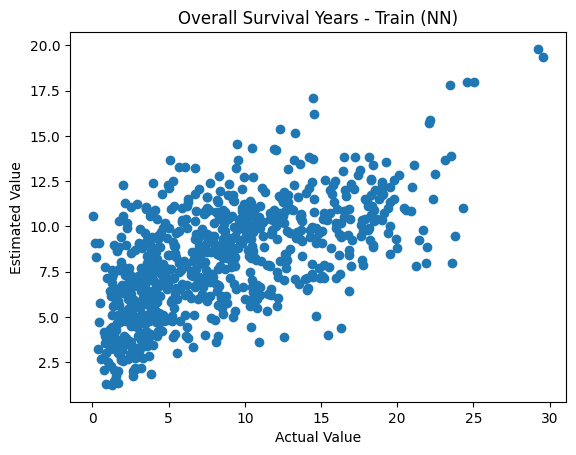


torch.Size([5, 576]) torch.Size([5, 1]) torch.Size([5, 1])
[array([11.351536 ,  8.878227 ,  4.9447327,  1.4041922,  8.585309 ,
        5.74407  ,  7.492137 ,  5.2968693, 10.93497  ,  9.532831 ,
       12.498897 ,  4.6281414, 10.946043 ,  5.456646 , 11.032347 ,
        4.591525 ,  7.035121 , 11.488541 ,  4.206601 ,  7.6418   ,
       12.891067 ,  8.030883 ,  3.6892776,  6.6124516,  8.124125 ,
        7.678935 , 21.338245 ,  9.22695  ,  2.2588966,  8.308818 ,
        8.0843315,  6.4976707], dtype=float32), array([ 8.762983 ,  3.3146968, 11.363415 ,  8.980274 ,  4.9291325,
       11.96596  ,  8.766806 ,  5.636269 ,  8.430688 , 10.1001625,
       12.440235 ,  5.171261 ,  8.69251  ,  4.566577 ,  2.9068258,
       10.096154 ,  3.6451275,  7.8762183, 11.193932 ,  8.473286 ,
       13.130493 ,  8.593879 ,  5.8177485,  5.433488 , 12.098486 ,
       10.749737 ,  9.619765 , 10.4513   ,  7.677965 ,  6.051103 ,
        8.177405 ,  6.804782 ], dtype=float32), array([ 1.6720967,  5.769896 ,  9.91906

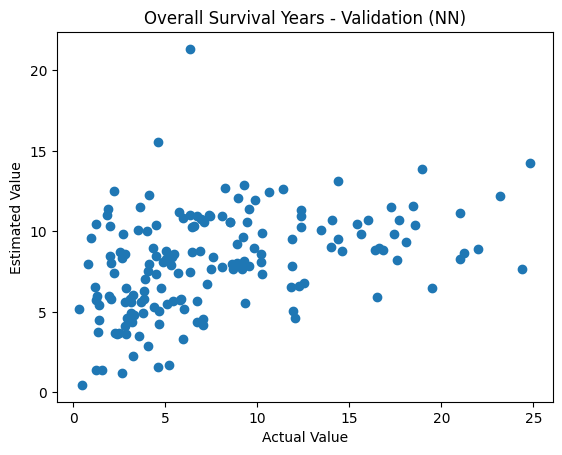


torch.Size([6, 576]) torch.Size([6, 1]) torch.Size([6, 1])
[array([ 9.755026 , 10.79201  , 10.137421 , 10.373978 ,  5.478703 ,
        2.4460573,  6.5015154,  9.468688 ,  9.981253 , 10.5946045,
        4.801632 ,  1.6832376,  9.959995 ,  6.7456307, 11.384833 ,
        5.2721105,  8.11948  , 11.354776 ,  9.41403  ,  8.2099   ,
        6.422309 ,  8.021342 ,  8.061366 ,  7.7383666,  5.5537367,
       11.845039 ,  8.34531  , 10.109364 , 10.726148 ,  9.726614 ,
        7.6217594,  7.453797 ], dtype=float32), array([ 6.0807676, 12.274558 ,  6.4207673, 12.582697 , 12.696894 ,
        9.445342 ,  9.890774 ,  9.174673 ,  8.108314 ,  2.5462158,
        3.4485958,  4.3223906,  7.7871823,  7.385254 ,  7.023749 ,
        5.6657653, 12.504689 ,  6.8427424,  2.0477138,  8.231688 ,
       11.487246 , 10.308556 , 11.446917 ,  3.1357949,  8.9052515,
        4.2617817,  9.295099 ,  7.8604593,  7.9468174,  3.6930003,
        8.798144 , 10.25353  ], dtype=float32), array([ 4.436677 , 10.190639 ,  9.31799

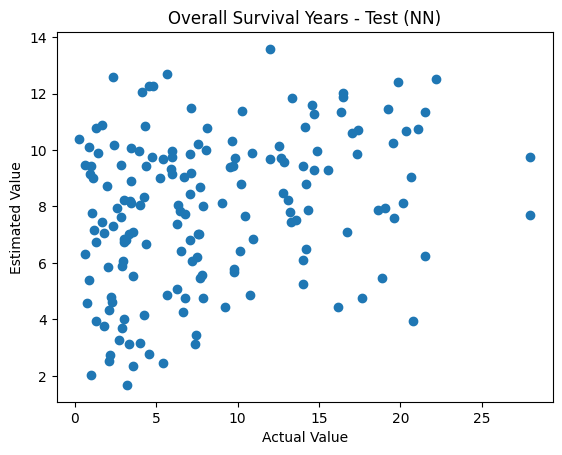

In [ ]:
def evaluate_split(name, model, loader):
  y_true = []
  y_pred = []
  model.eval()

  for xb, yb in loader:
    xb, yb = xb.to(device), yb.to(device)
    preds = model(xb)
    y_true.append(yb.cpu().detach().numpy().flatten())
    y_pred.append(preds.cpu().detach().numpy().flatten())

  print(xb.size(), yb.size(), preds.size())
  print(y_pred)

  y_true = np.hstack(y_true)
  y_pred = np.hstack(y_pred)
  print(y_true.shape, y_pred.shape)

  pearson, _ = stats.pearsonr(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)

  print(f"{name} set:")
  print(f"pearson = {pearson}")
  print(f"r2 = {r2}")
  print(f"mse = {mse}")

  plt.figure()
  plt.scatter(y_true, y_pred)
  plt.xlabel("Actual Value")
  plt.ylabel("Estimated Value")
  plt.title(f"Overall Survival Years - {name}")
  plt.show()

  print()

  return y_pred, pearson, r2

y_train_pred, train_pearson, train_r2 = evaluate_split("Train (NN)", model, train_loader)
y_val_pred, val_pearson, val_r2 = evaluate_split("Validation (NN)", model, val_loader)
y_test_pred, test_pearson, test_r2  = evaluate_split("Test (NN)", model, test_loader)

In [ ]:
import shap
import random
# Convert your model to a format compatible with SHAP
def model_predict(x):
  model.eval()
  with torch.no_grad():
    # Ensure x is a tensor and moved to the correct device
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    return model(x_tensor).cpu().numpy().squeeze(-1)

# Select examples for which to compute SHAP values
random_indices = random.sample(range(X_train.shape[0]), 100)
X_train_sample = X_train[random_indices].cpu().numpy() # Convert to numpy for SHAP

# Get feature names from the main_df before dropping the target column
feature_names = main_df.drop(columns=['time_until_death']).columns.tolist()

# Use shap.sample to summarize the background dataset for the explainer
background_data = shap.sample(X_train.cpu().numpy(), 100) # Sample 100 instances from X_train

# Create a SHAP explainer
explainer = shap.KernelExplainer(model_predict, background_data)
# Compute SHAP values for the sample of your data
shap_values_raw = explainer.shap_values(X_train_sample)

# Create a shap.Explanation object
shap_explanation = shap.Explanation(
    values=shap_values_raw,
    base_values=explainer.expected_value,
    data=X_train_sample,
    feature_names=feature_names
)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
shap.plots.bar(shap_explanation, max_display=99, show=False)
plt.gcf()
plt.savefig("plots/bar.png")
plt.show()

AttributeError: 'float' object has no attribute 'shape'

In [ ]:
shap.plots.beeswarm(shap_explanation, max_display=99, show=False)
plt.gcf()
plt.savefig("plots/beeswarm.png")
plt.show()

In [ ]:
'''
for: nn.Linear(in_features, 32), # Layer 1
      nn.ReLU(),
      nn.Linear(32, 1), # Layer 4 (output)
      nn.ReLU() # ensure output >= 0


OLD CODE

Test Pearson:
mean = 0.260
5% CI = [0.111, 0.398]

Test r2:
mean = -0.196
95% CI = [-0.448, 0.025]

Test mse:
mse = 47.043
95% CI = [37.110, 58.701]


AFTER CHECKPOINT

Test Pearson:
mean = 0.355
5% CI = [0.213, 0.477]

Test r2:
mean = 0.101
95% CI = [-0.016, 0.204]

Test mse:
mse = 35.532
95% CI = [27.283, 45.059]


'''

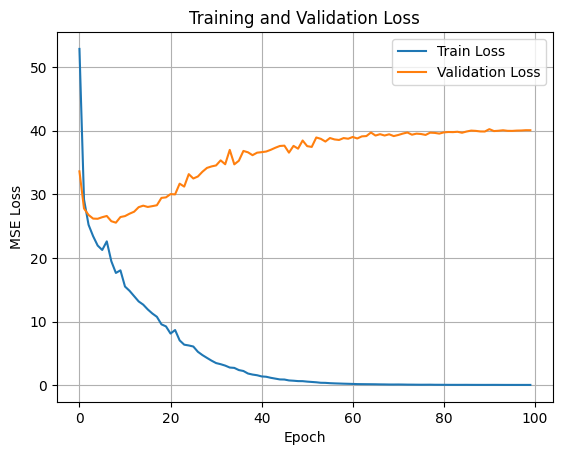

In [ ]:
'''
BEST SO FAR?

for: nn.Linear(in_features, 64), # Layer 1
      nn.ReLU(),
      nn.Linear(64, 32), # Layer 3
      nn.ReLU(),
      nn.Linear(32, 1), # Layer 4 (output)
      nn.ReLU() # ensure output >= 0

Test Pearson:
mean = 0.364
5% CI = [0.224, 0.489]

Test r2:
mean = 0.112
95% CI = [-0.010, 0.219]

Test mse:
mse = 35.073
95% CI = [27.101, 44.237]

'''

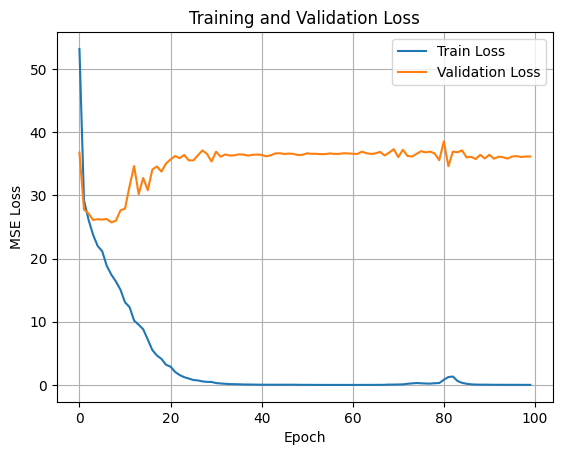

In [ ]:
'''
for: nn.Linear(in_features, 64), # Layer 1
      nn.ReLU(),
      nn.Linear(64, 64), # Layer 2
      nn.ReLU(),
      nn.Linear(64, 32), # Layer 3
      nn.ReLU(),
      nn.Linear(32, 1), # Layer 4 (output)
      nn.ReLU() # ensure output >= 0

Test Pearson:
mean = 0.361
5% CI = [0.224, 0.484]

Test r2:
mean = 0.108
95% CI = [-0.005, 0.210]

Test mse:
mse = 35.254
95% CI = [27.149, 44.412]

'''

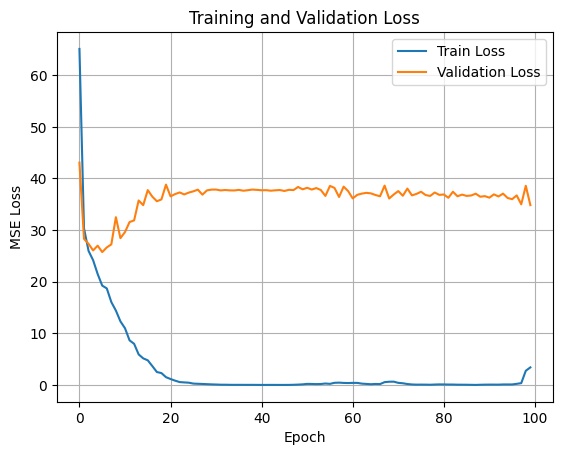

In [ ]:
'''
for: nn.Linear(in_features, 32), # Layer 1
      nn.ReLU(),
      # nn.Linear(64, 64), # Layer 2
      # nn.ReLU(),
      nn.Linear(32, 16), # Layer 3
      nn.ReLU(),
      nn.Linear(16, 1), # Layer 4 (output)
      nn.ReLU() # ensure output >= 0



'''